In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [8]:
def load_data(filepath):
    return pd.read_excel(filepath)

df = load_data("DataScience(Week3_Assignment).xlsx")
df.head()

,converted_speedColor,converted_speedMono,deviceProductFamily,deviceType,guid,listPrice,make,model,printTechnology,productNumber,...,region,country,width,depth,height,weight,standardInputCapacity,printDPI,scan,hasWifi
0,0.0,600.0,ad acl 7350/7450,dot matrix,AD0001,1861.24,amt datasouth,Accel 7350,dot matrix,AMT7350,...,North America,United States,25.0,18.3,11.6,51.81,0,360 x 360,False,False
1,0.0,600.0,ad acl 7350/7450,dot matrix,AD0002,2304.99,amt datasouth,ACCEL-7450,dot matrix,AMT7450,...,North America,United States,25.0,18.3,11.6,52.00,0,360 x 360,False,False
2,0.0,600.0,ad acl 6310/6350,dot matrix,AD0003,1748.49,amt datasouth,ACCEL 6350,dot matrix,A6350,...,North America,United States,24.0,16.8,8.2,44.97,0,360 x 240,False,False
3,4.0,7.0,ao p 2600p/2600u,printcolor,AO0007,457.27,apollo,P-2600P,inkjet,P2600P,...,North America,United States,18.6,15.4,8.7,11.90,100,600 x 600,False,False
4,1.5,3.5,ao p 1250i,printcolor,AO0008,586.12,apollo,P-1250i,inkjet,P1250I,...,North America,United States,13.7,6.4,6.9,6.61,50,600 x 300,False,False


In [9]:
def check_data(dataframe):
    dataframe.info()
    return dataframe.isnull().sum()

check_data(df)

<class 'pandas.DataFrame'>
RangeIndex: 11878 entries, 0 to 11877
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   converted_speedColor   11878 non-null  float64
 1   converted_speedMono    11878 non-null  float64
 2   deviceProductFamily    11878 non-null  str    
 3   deviceType             11878 non-null  str    
 4   guid                   11878 non-null  str    
 5   listPrice              11878 non-null  float64
 6   make                   11878 non-null  str    
 7   model                  11878 non-null  str    
 8   printTechnology        11878 non-null  str    
 9   productNumber          11878 non-null  str    
 10  assetClass             11878 non-null  str    
 11  region                 11878 non-null  str    
 12  country                11878 non-null  str    
 13  width                  11878 non-null  float64
 14  depth                  11878 non-null  float64
 15  height       

converted_speedColor     0
converted_speedMono      0
deviceProductFamily      0
deviceType               0
guid                     0
listPrice                0
make                     0
model                    0
printTechnology          0
productNumber            0
assetClass               0
region                   0
country                  0
width                    0
depth                    0
height                   0
weight                   0
standardInputCapacity    0
printDPI                 0
scan                     0
hasWifi                  0
dtype: int64

In [10]:
def drop_columns(dataframe, columns):
    return dataframe.drop(columns=columns)

def rename_columns(dataframe, mapping):
    return dataframe.rename(columns=mapping)

df = drop_columns(df, ['country', 'region'])
df = rename_columns(df, {'converted_speedColor': 'SpeedColor', 'converted_speedMono': 'SpeedMono'})
df.head()

,SpeedColor,SpeedMono,deviceProductFamily,deviceType,guid,listPrice,make,model,printTechnology,productNumber,assetClass,width,depth,height,weight,standardInputCapacity,printDPI,scan,hasWifi
0,0.0,600.0,ad acl 7350/7450,dot matrix,AD0001,1861.24,amt datasouth,Accel 7350,dot matrix,AMT7350,Home/Small Office/Workgroup,25.0,18.3,11.6,51.81,0,360 x 360,False,False
1,0.0,600.0,ad acl 7350/7450,dot matrix,AD0002,2304.99,amt datasouth,ACCEL-7450,dot matrix,AMT7450,Home/Small Office/Workgroup,25.0,18.3,11.6,52.00,0,360 x 360,False,False
2,0.0,600.0,ad acl 6310/6350,dot matrix,AD0003,1748.49,amt datasouth,ACCEL 6350,dot matrix,A6350,Workgroup,24.0,16.8,8.2,44.97,0,360 x 240,False,False
3,4.0,7.0,ao p 2600p/2600u,printcolor,AO0007,457.27,apollo,P-2600P,inkjet,P2600P,Home/Small Office/Workgroup,18.6,15.4,8.7,11.90,100,600 x 600,False,False
4,1.5,3.5,ao p 1250i,printcolor,AO0008,586.12,apollo,P-1250i,inkjet,P1250I,Home/Small Office/Workgroup,13.7,6.4,6.9,6.61,50,600 x 300,False,False


In [11]:
def transform_dpi(dataframe):
    dpi = dataframe['printDPI'].str.lower().str.replace(' ', '').str.split('x', expand=True)
    dataframe['printDPI_numeric'] = pd.to_numeric(dpi[0], errors='coerce') * pd.to_numeric(dpi[1], errors='coerce')
    return dataframe

df = transform_dpi(df)
df[['printDPI', 'printDPI_numeric']].head(10)


,printDPI,printDPI_numeric
0,360 x 360,129600.0
1,360 x 360,129600.0
2,360 x 240,86400.0
3,600 x 600,360000.0
4,600 x 300,180000.0
5,600 x 600,360000.0
6,600 x 600,360000.0
7,600 x 600,360000.0
8,600 x 300,180000.0
9,600 x 300,180000.0


In [12]:
def min_max_scale(series):
    min_val = series.min()
    max_val = series.max()
    if max_val == min_val:
        return series * 0
    return (series - min_val) / (max_val - min_val)

df['dpi_scaled_printTech'] = df.groupby('printTechnology')['printDPI_numeric'].transform(min_max_scale)
df['dpi_scaled_assetClass'] = df.groupby('assetClass')['printDPI_numeric'].transform(min_max_scale)

df[['printTechnology', 'assetClass', 'printDPI_numeric', 'dpi_scaled_printTech', 'dpi_scaled_assetClass']].head(10)

,printTechnology,assetClass,printDPI_numeric,dpi_scaled_printTech,dpi_scaled_assetClass
0,dot matrix,Home/Small Office/Workgroup,129600.0,0.009450,0.001250
1,dot matrix,Home/Small Office/Workgroup,129600.0,0.009450,0.001250
2,dot matrix,Workgroup,86400.0,0.006115,0.001289
3,inkjet,Home/Small Office/Workgroup,360000.0,0.013913,0.003751
4,inkjet,Home/Small Office/Workgroup,180000.0,0.006087,0.001797
5,inkjet,Home/Small Office/Workgroup,360000.0,0.013913,0.003751
6,inkjet,Home/Small Office/Workgroup,360000.0,0.013913,0.003751
7,inkjet,Home/Small Office/Workgroup,360000.0,0.013913,0.003751
8,inkjet,Small/Medium Workgroup,180000.0,0.006087,0.002696
9,inkjet,Small/Medium Workgroup,180000.0,0.006087,0.002696


In [13]:
cols = ['SpeedColor', 'SpeedMono', 'listPrice', 'width', 'depth', 'height', 'weight', 'standardInputCapacity']

In [14]:
def calc_mean(dataframe, columns):
    return dataframe[columns].mean()

def calc_median(dataframe, columns):
    return dataframe[columns].median()

def calc_mode(dataframe, columns):
    return dataframe[columns].mode().iloc[0]

def calc_std(dataframe, columns):
    return dataframe[columns].std()

pd.DataFrame({'mean': calc_mean(df, cols), 'median': calc_median(df, cols), 'mode': calc_mode(df, cols), 'std': calc_std(df, cols)})

,mean,median,mode,std
SpeedColor,19.352323,2.700,0.00,303.340260
SpeedMono,51.799728,28.000,35.00,422.140735
listPrice,7819.216068,1299.000,199.99,32516.045650
width,23.649937,18.900,16.50,22.450032
depth,22.033379,19.500,26.00,43.693563
height,21.772077,16.540,0.00,20.799448
weight,181.707994,50.795,0.00,881.016573
standardInputCapacity,761.502273,350.000,0.00,1234.715944


In [15]:
def calc_percentiles(dataframe, columns):
    return dataframe[columns].quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

calc_percentiles(df, cols)

,SpeedColor,SpeedMono,listPrice,width,depth,height,weight,standardInputCapacity
0.01,0.00,1.0,68.8501,3.054,2.0616,1.134,0.000,0.0
0.05,0.00,6.0,134.6930,11.700,8.4985,5.600,5.510,0.0
0.10,0.00,8.2,199.9500,14.400,11.4000,6.500,10.000,0.0
0.25,0.00,17.0,399.0000,16.530,15.3000,9.600,19.185,120.0
0.50,2.70,28.0,1299.0000,18.900,19.5000,16.540,50.795,350.0
0.75,22.00,45.0,5995.0000,24.400,26.0000,30.000,163.140,1050.0
0.90,40.00,70.0,17542.9690,34.886,30.3000,45.300,326.280,1750.0
0.95,55.00,102.0,30512.7395,51.900,34.0000,48.400,520.405,3500.0
0.99,110.23,355.6,102598.2700,100.069,47.0000,64.115,2179.980,4600.0


In [16]:
def calc_quartiles(dataframe, columns):
    return dataframe[columns].quantile([0.25, 0.50, 0.75])

def calc_quintiles(dataframe, columns):
    return dataframe[columns].quantile([0.2, 0.4, 0.6, 0.8])

def calc_deciles(dataframe, columns):
    return dataframe[columns].quantile([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

print('Quartiles:')
display(calc_quartiles(df, cols))
print('Quintiles:')
display(calc_quintiles(df, cols))
print('Deciles:')
display(calc_deciles(df, cols))

Quartiles:


,SpeedColor,SpeedMono,listPrice,width,depth,height,weight,standardInputCapacity
0.25,0.0,17.0,399.0,16.53,15.3,9.60,19.185,120.0
0.50,2.7,28.0,1299.0,18.90,19.5,16.54,50.795,350.0
0.75,22.0,45.0,5995.0,24.40,26.0,30.00,163.140,1050.0


Quintiles:


,SpeedColor,SpeedMono,listPrice,width,depth,height,weight,standardInputCapacity
0.2,0.0,15.0,331.336,16.0,14.5,8.460,15.87,100.0
0.4,0.0,24.0,749.000,17.6,17.7,13.564,36.00,250.0
0.6,8.0,33.0,2393.656,21.4,21.9,19.900,75.00,600.0
0.8,26.0,50.0,8200.000,26.0,26.9,34.000,191.48,1100.0


Deciles:


,SpeedColor,SpeedMono,listPrice,width,depth,height,weight,standardInputCapacity
0.1,0.0,8.2,199.950,14.400,11.4,6.500,10.000,0.0
0.2,0.0,15.0,331.336,16.000,14.5,8.460,15.870,100.0
0.3,0.0,20.0,496.350,16.890,16.0,10.600,23.800,150.0
0.4,0.0,24.0,749.000,17.600,17.7,13.564,36.000,250.0
0.5,2.7,28.0,1299.000,18.900,19.5,16.540,50.795,350.0
0.6,8.0,33.0,2393.656,21.400,21.9,19.900,75.000,600.0
0.7,18.0,40.0,4250.000,23.300,25.0,26.889,126.000,650.0
0.8,26.0,50.0,8200.000,26.000,26.9,34.000,191.480,1100.0
0.9,40.0,70.0,17542.969,34.886,30.3,45.300,326.280,1750.0


In [17]:
def calc_iqr(dataframe, columns):
    q1 = dataframe[columns].quantile(0.25)
    q3 = dataframe[columns].quantile(0.75)
    return q3 - q1

calc_iqr(df, cols)

SpeedColor                 22.000
SpeedMono                  28.000
listPrice                5596.000
width                       7.870
depth                      10.700
height                     20.400
weight                    143.955
standardInputCapacity     930.000
dtype: float64

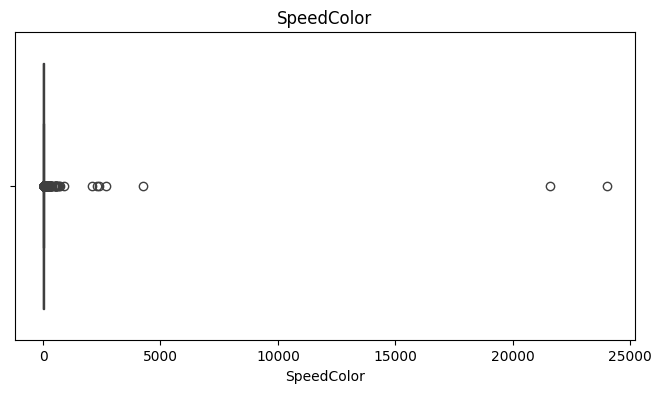

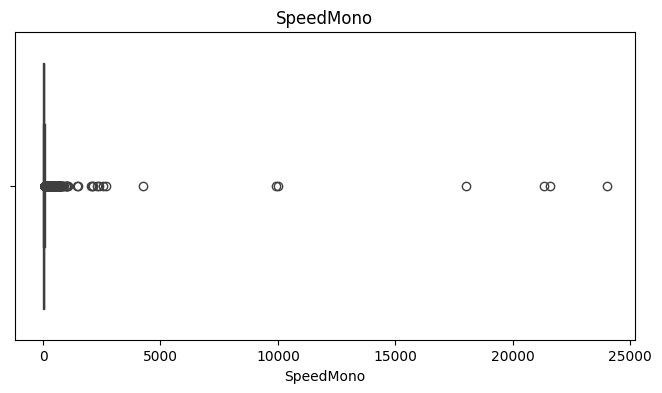

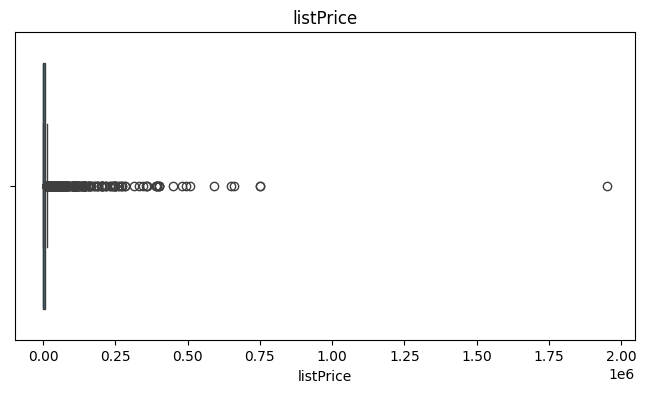

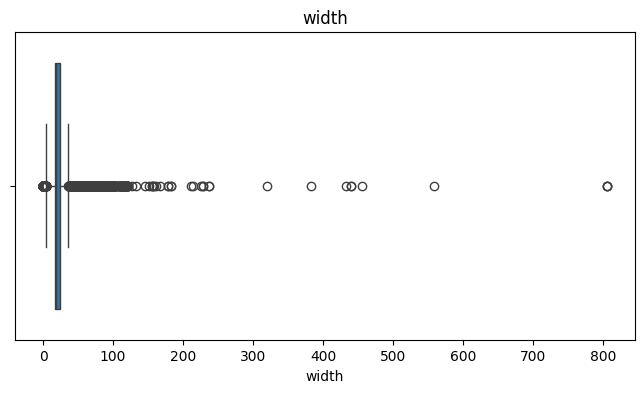

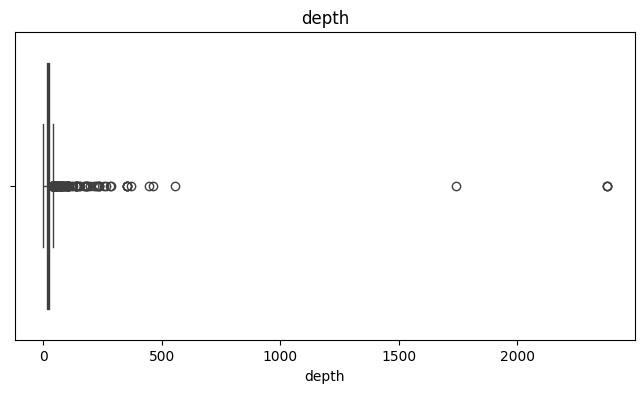

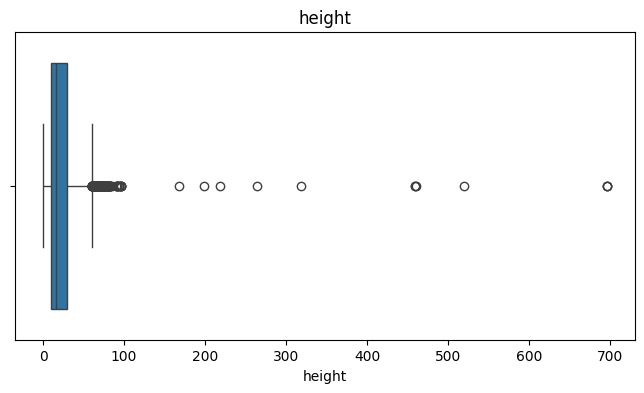

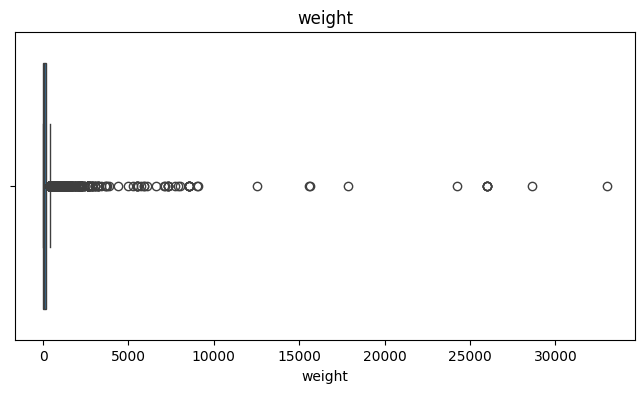

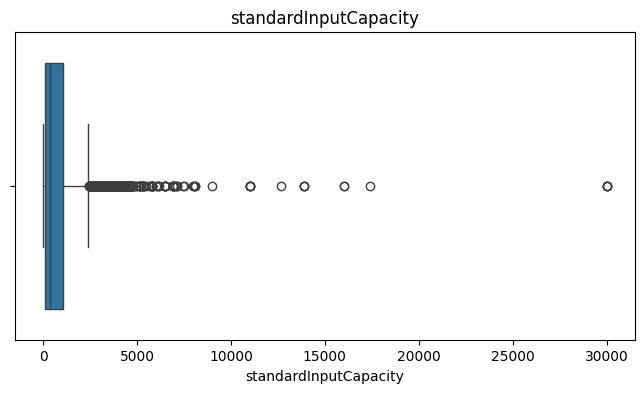

In [18]:
def plot_boxplot(dataframe, feature):
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=dataframe[feature])
    plt.title(feature)
    plt.show()

for col in cols:
    plot_boxplot(df, col)

In [19]:
def calc_grouped_iqr(dataframe, group_col, feature_cols):
    q3 = dataframe.groupby(group_col)[feature_cols].quantile(0.75)
    q1 = dataframe.groupby(group_col)[feature_cols].quantile(0.25)
    return q3 - q1

calc_grouped_iqr(df, 'printTechnology', cols)

,SpeedColor,SpeedMono,listPrice,width,depth,height,weight,standardInputCapacity
printTechnology,,,,,,,,
direct thermal/thermal transfer,0.00,192.988333,1164.6750,5.1800,9.4950,6.9650,31.0500,0.0
dot matrix,0.00,297.500000,343.0500,8.2000,3.6000,3.1750,13.1025,0.0
dye sublimation/thermal resin,0.00,0.000000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0
dye-sublimation / retransfer,0.00,0.000000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0
fused deposition,0.00,0.000000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0
inkjet,15.00,17.000000,423.0150,3.1550,7.7375,5.9075,17.0500,70.0
laser,25.00,23.000000,8218.0400,9.0000,9.4000,19.3000,164.0000,850.0
line thermal,0.00,974.000000,5975.0100,15.1000,23.2000,29.1000,279.5500,0.0
multi jet fusion,27.75,154.500000,150750.0000,25.4000,10.1500,3.5000,291.7500,0.0


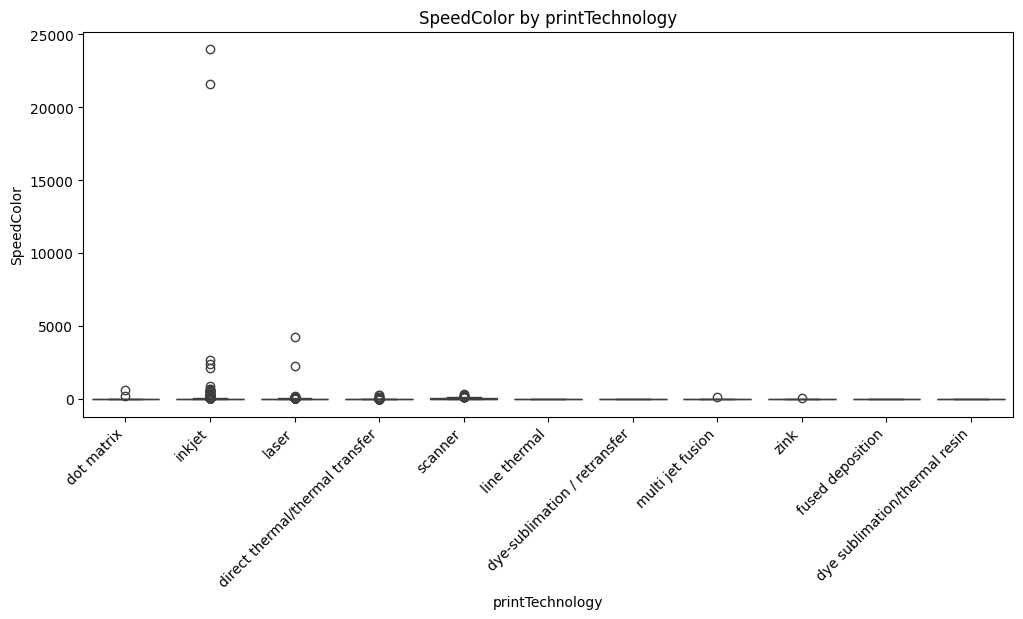

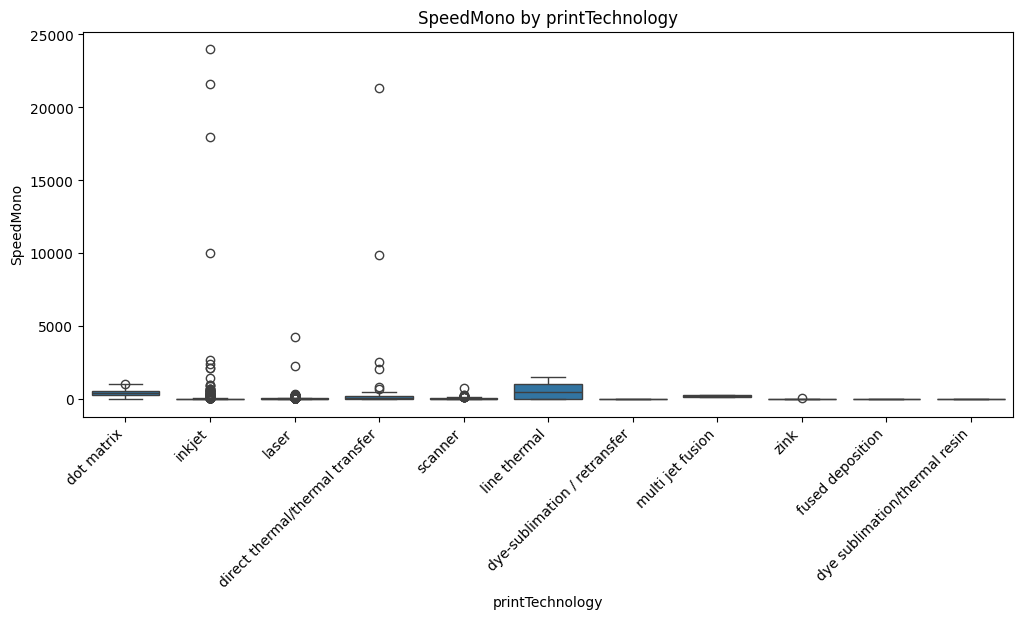

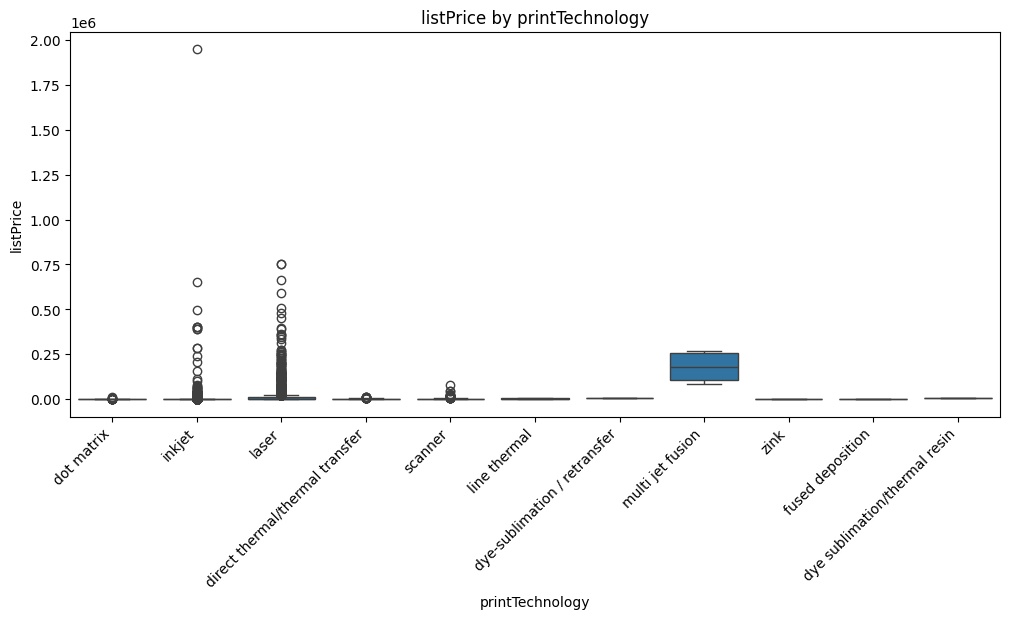

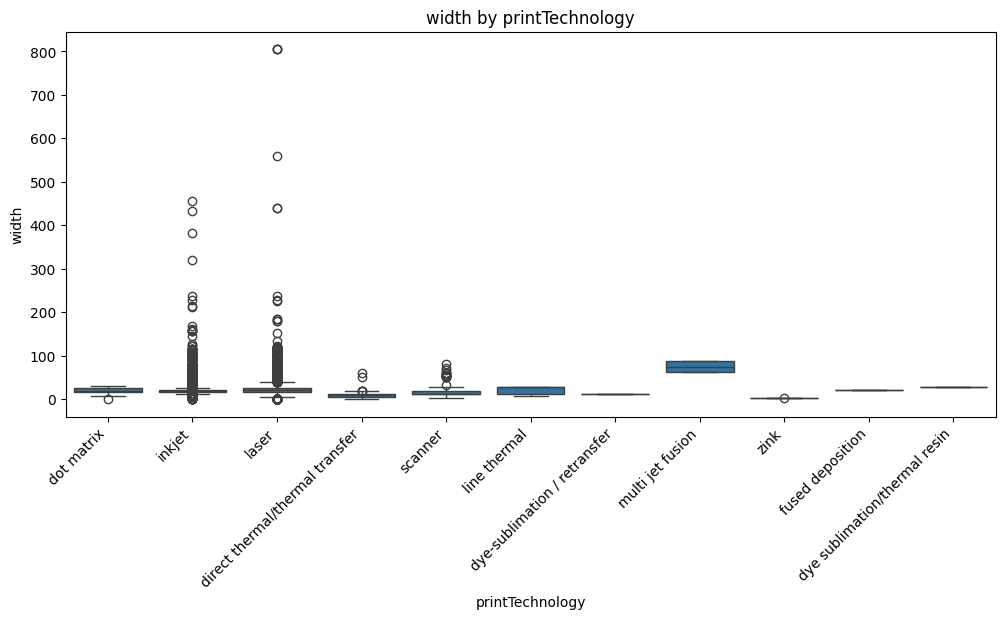

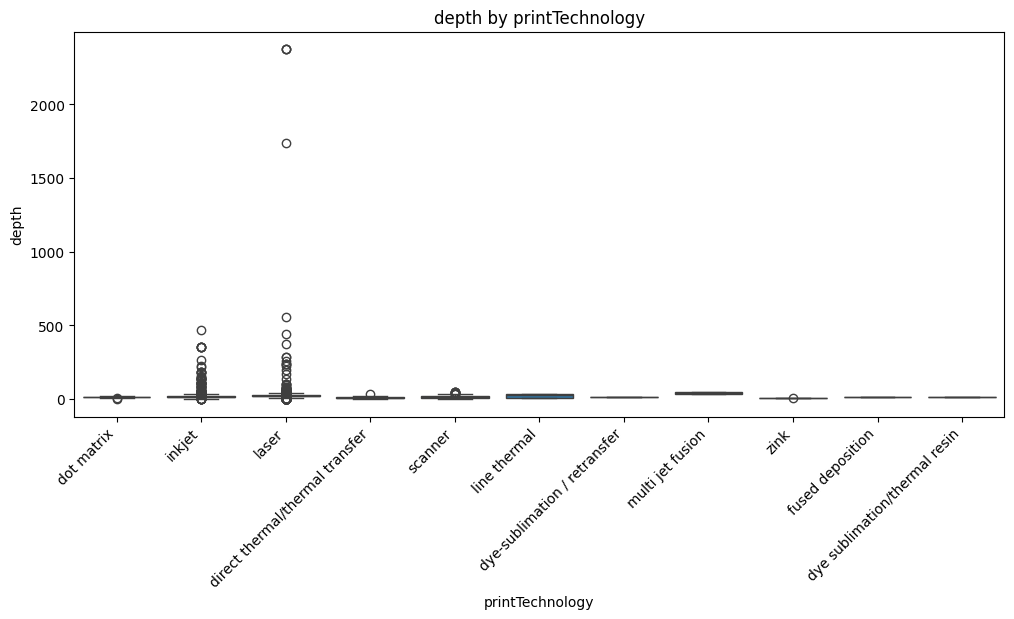

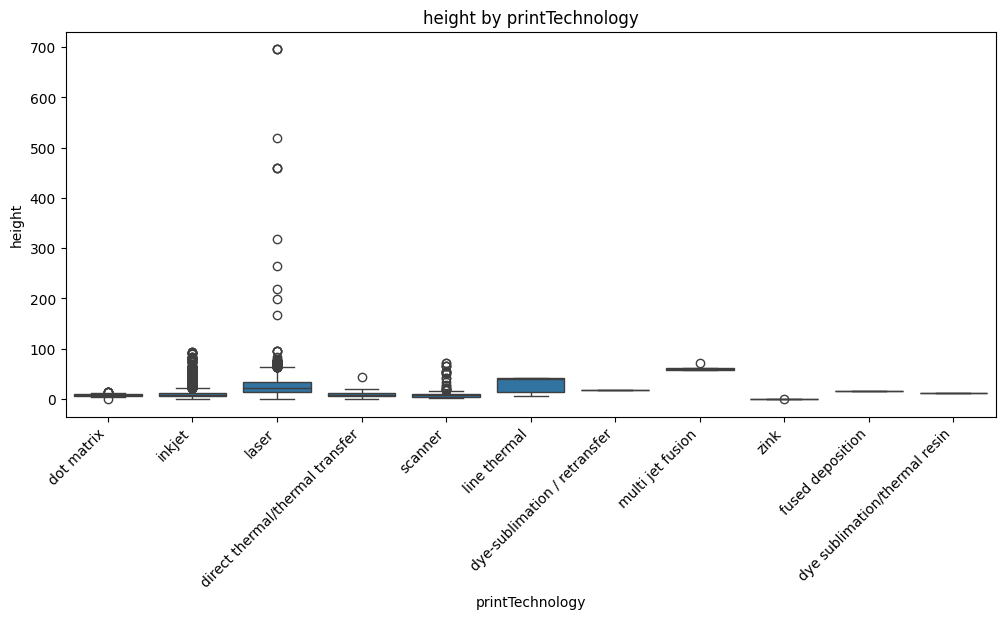

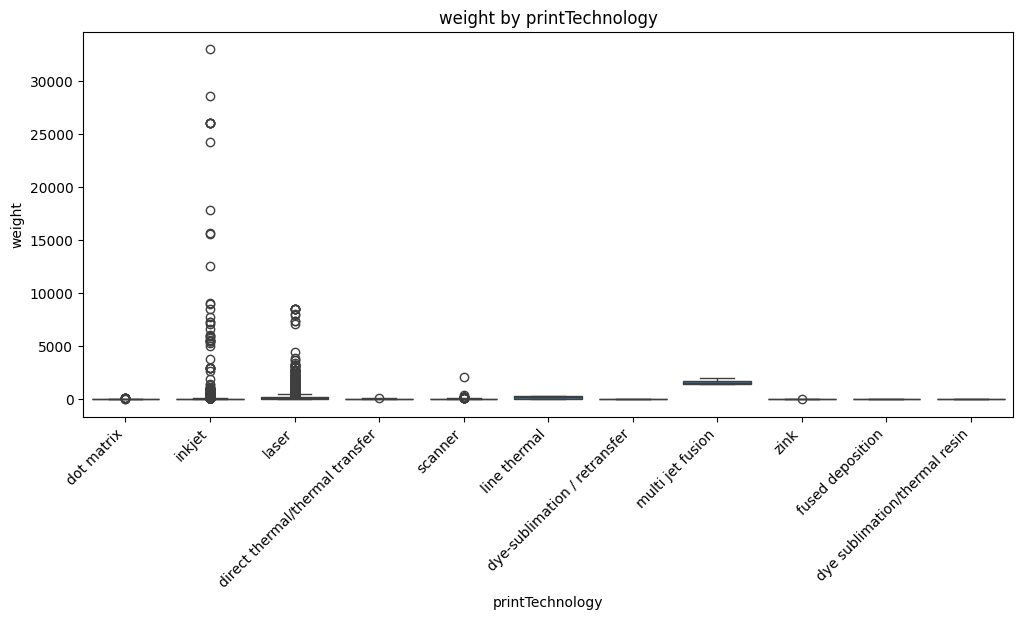

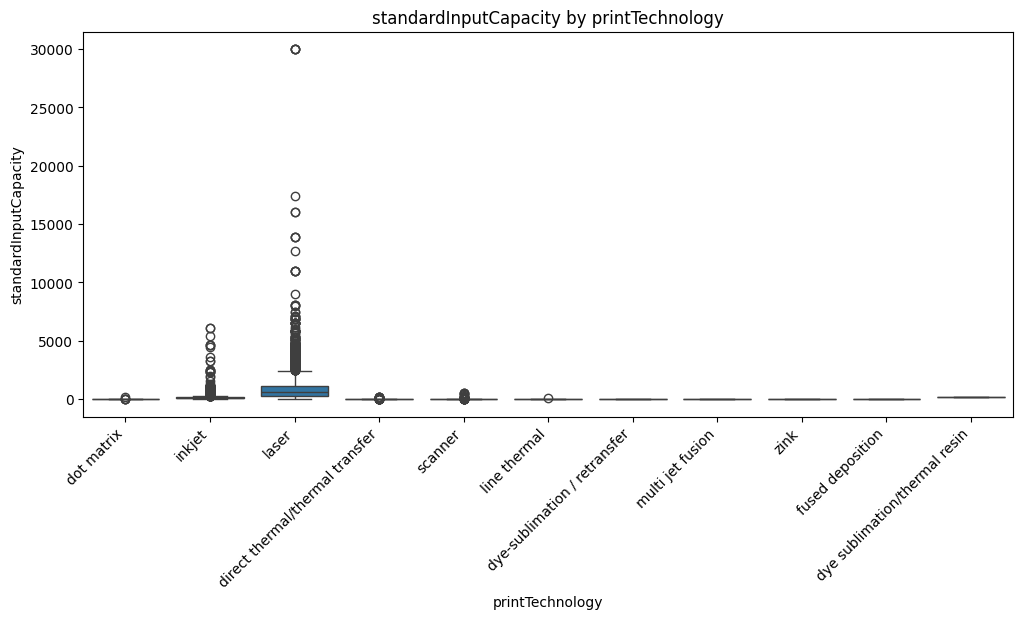

In [20]:
def plot_grouped_boxplot(dataframe, feature, group_col):
    plt.figure(figsize=(12, 5))
    sns.boxplot(data=dataframe, x=group_col, y=feature)
    plt.xticks(rotation=45, ha='right')
    plt.title(f'{feature} by {group_col}')
    plt.show()

for col in cols:
    plot_grouped_boxplot(df, col, 'printTechnology')

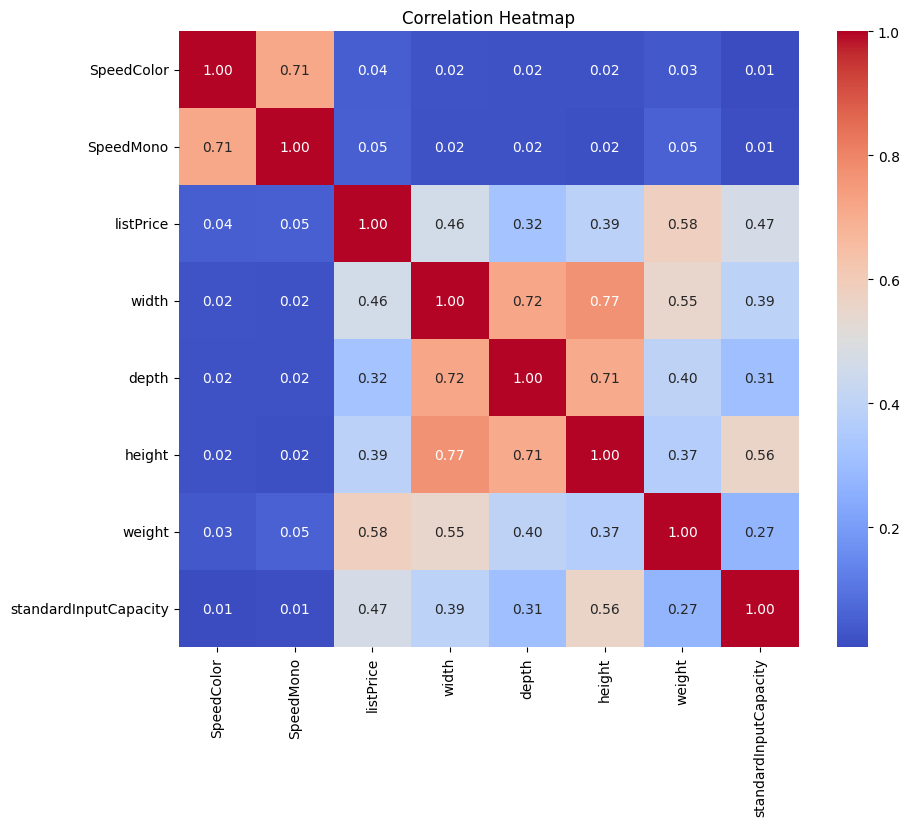

In [21]:
def calc_correlation(dataframe, columns):
    return dataframe[columns].corr()

def plot_heatmap(corr_matrix):
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Correlation Heatmap')
    plt.show()

corr_matrix = calc_correlation(df, cols)
plot_heatmap(corr_matrix)

In [22]:
def perform_z_test(data, pop_mean, pop_std):
    z_stat = (data.mean() - pop_mean) / (pop_std / np.sqrt(len(data)))
    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))
    return z_stat, p_value

def perform_t_test(data, pop_mean):
    t_stat, p_value = stats.ttest_1samp(data, pop_mean)
    return t_stat, p_value

results = []
for col in cols:
    data = df[col].dropna()
    z_stat, z_p = perform_z_test(data, data.mean(), data.std())
    t_stat, t_p = perform_t_test(data, data.mean())
    results.append({'feature': col, 'z_stat': round(z_stat, 4), 'z_pvalue': round(z_p, 4), 't_stat': round(t_stat, 4), 't_pvalue': round(t_p, 4)})

pd.DataFrame(results)

,feature,z_stat,z_pvalue,t_stat,t_pvalue
0,SpeedColor,0.0,1.0,0.0,1.0
1,SpeedMono,0.0,1.0,0.0,1.0
2,listPrice,0.0,1.0,0.0,1.0
3,width,0.0,1.0,0.0,1.0
4,depth,0.0,1.0,0.0,1.0
5,height,0.0,1.0,0.0,1.0
6,weight,0.0,1.0,0.0,1.0
7,standardInputCapacity,0.0,1.0,0.0,1.0


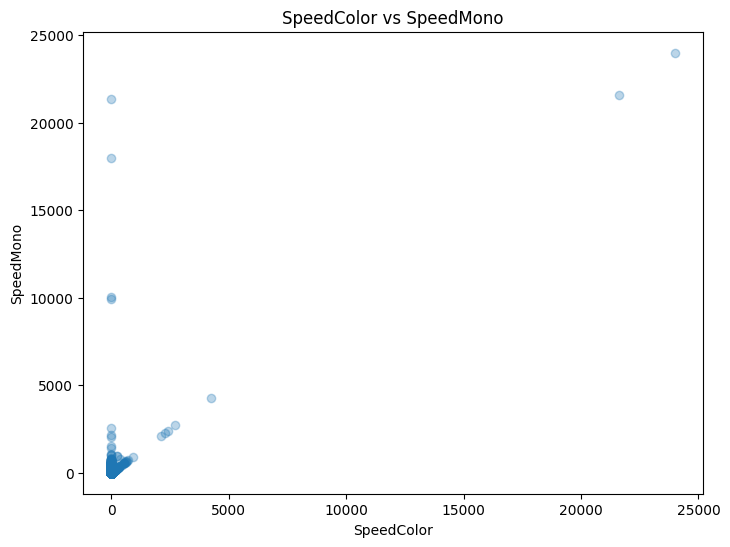

Correlation: 0.7143


In [23]:
def check_speed_relationship(dataframe):
    speed_data = dataframe[['SpeedColor', 'SpeedMono']].dropna()
    corr_val = speed_data['SpeedColor'].corr(speed_data['SpeedMono'])
    
    plt.figure(figsize=(8, 6))
    plt.scatter(speed_data['SpeedColor'], speed_data['SpeedMono'], alpha=0.3)
    plt.xlabel('SpeedColor')
    plt.ylabel('SpeedMono')
    plt.title('SpeedColor vs SpeedMono')
    plt.show()
    
    return corr_val

corr = check_speed_relationship(df)
print(f'Correlation: {corr:.4f}')

In [24]:
def find_outlier_guids(dataframe, group_cols, feature, threshold=3):
    def get_zscore(group):
        mean_val = group.mean()
        std_val = group.std()
        if std_val == 0:
            return pd.Series(0, index=group.index)
        return (group - mean_val) / std_val
    
    dataframe = dataframe.copy()
    dataframe['z_score'] = dataframe.groupby(group_cols)[feature].transform(get_zscore)
    outliers = dataframe[abs(dataframe['z_score']) > threshold]
    return outliers[['guid'] + group_cols + [feature, 'z_score']]

find_outlier_guids(df, ['deviceType', 'printTechnology', 'assetClass'], 'listPrice')

,guid,deviceType,printTechnology,assetClass,listPrice,z_score
677,BR0806,label printer,direct thermal/thermal transfer,Small/Medium Workgroup,589.95,3.456057
706,CA0001,label printer,direct thermal/thermal transfer,Enterprise/Industrial/Large workgroup,9075.00,4.237046
707,CA0002,label printer,direct thermal/thermal transfer,Enterprise/Industrial/Large workgroup,10999.00,5.320119
785,CN0477,multifunctionmono,laser,Workgroup,52500.00,3.473796
817,CN1055,printcolor,inkjet,Workgroup,63435.66,8.867697
...,...,...,...,...,...,...
11689,XE0178,multifunctionmono,laser,Workgroup,67269.36,4.630451
11690,XE0179,printmono,laser,Workgroup,82652.40,3.023112
11803,XE0955,scanner,laser,Personal/Small Office/Home Office Workgroup,3363.52,3.588880
11837,ZE0052,label printer,direct thermal/thermal transfer,Enterprise/Industrial/Large workgroup,10037.00,4.778583


In [25]:
def get_group_variance(dataframe, device_type, print_tech, asset_class, feature):
    filtered = dataframe[
        (dataframe['deviceType'] == device_type) &
        (dataframe['printTechnology'] == print_tech) &
        (dataframe['assetClass'] == asset_class)
    ]
    return filtered[feature].var(), len(filtered)

def f_ratio_test(var1, n1, var2, n2):
    f_stat = var1 / var2
    p_value = 1 - stats.f.cdf(f_stat, n1 - 1, n2 - 1)
    return f_stat, p_value

var1, n1 = get_group_variance(df, 'multifunctionmono', 'laser', 'Workgroup', 'listPrice')
var2, n2 = get_group_variance(df, 'multifunctioncolor', 'laser', 'Workgroup', 'listPrice')
f_stat, p_val = f_ratio_test(var1, n1, var2, n2)

print(f'F-statistic: {f_stat:.4f}')
print(f'P-value: {p_val:.4f}')
if p_val < 0.05:
    print('Reject null hypothesis')
else:
    print('Fail to reject null hypothesis')

F-statistic: 1.1860
P-value: 0.0005
Reject null hypothesis


In [26]:
def categorize_by_percentile(dataframe, feature):
    percentiles = dataframe[feature].quantile([0.2, 0.4, 0.6, 0.8])
    
    def assign_class(value):
        if value <= percentiles[0.2]:
            return 'A'
        elif value <= percentiles[0.4]:
            return 'B'
        elif value <= percentiles[0.6]:
            return 'C'
        elif value <= percentiles[0.8]:
            return 'D'
        else:
            return 'E'
    
    return dataframe[feature].apply(assign_class)

df['price_class'] = categorize_by_percentile(df, 'listPrice')
df['price_class'].value_counts().sort_index()

price_class
A    2376
B    2376
C    2375
D    2376
E    2375
Name: count, dtype: int64

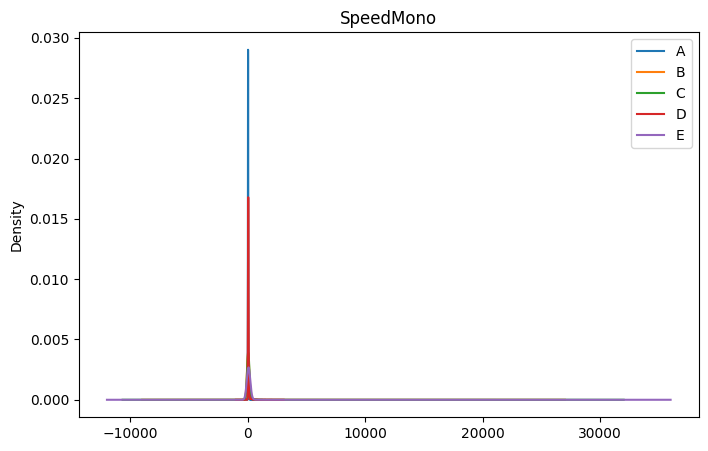

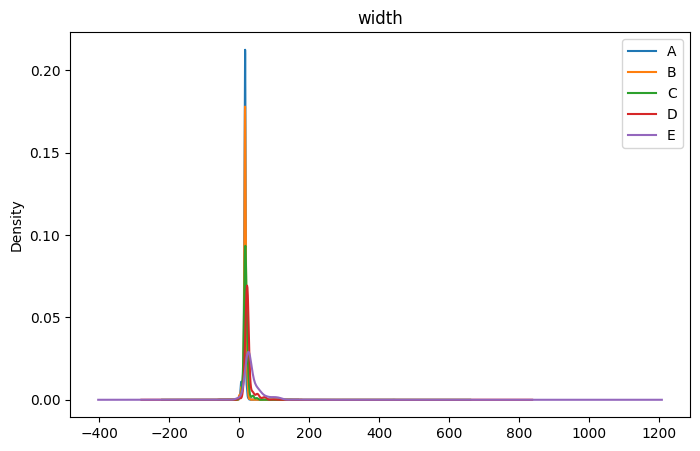

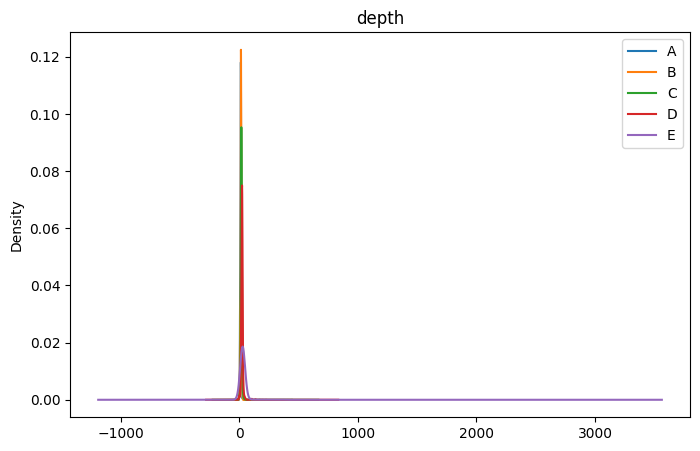

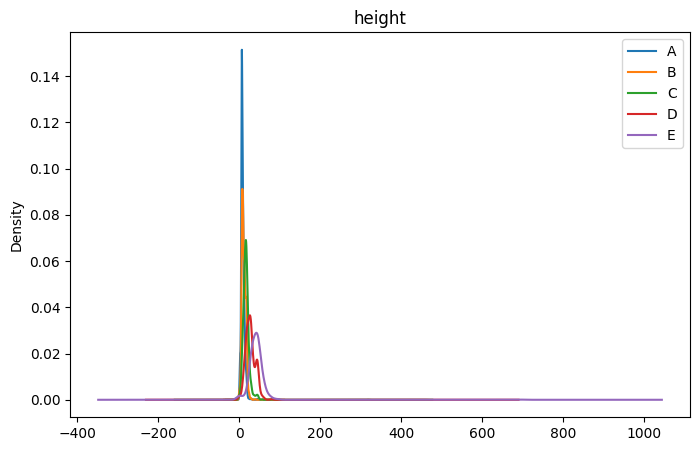

In [27]:
def plot_density(dataframe, feature, class_col):
    plt.figure(figsize=(8, 5))
    for cls in sorted(dataframe[class_col].unique()):
        dataframe[dataframe[class_col] == cls][feature].plot(kind='kde', label=cls)
    plt.title(feature)
    plt.legend()
    plt.show()

for feat in ['SpeedMono', 'width', 'depth', 'height']:
    plot_density(df, feat, 'price_class')

In [28]:
def perform_chi_square(dataframe, col1, col2):
    contingency_table = pd.crosstab(dataframe[col1], dataframe[col2])
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
    return chi2, p_value, dof, contingency_table

df_chi = df.copy()
df_chi['scan'] = df_chi['scan'].replace('Optional', False)
df_chi['hasWifi'] = df_chi['hasWifi'].replace('Optional', False)

chi2, p_val, dof, cont_table = perform_chi_square(df_chi, 'scan', 'hasWifi')

print(f'Chi-square: {chi2:.4f}, P-value: {p_val:.6f}, DOF: {dof}')
if p_val < 0.05:
    print('Reject null hypothesis')
else:
    print('Fail to reject null hypothesis')

Chi-square: 835.3429, P-value: 0.000000, DOF: 6
Reject null hypothesis
